# Exercise 4.4 : Random Walk Metropolis-Hastings vs. MALA
---

### Target Log-Density
We want to sample from the banana density $$p(x,y) \propto \exp\left(
-\frac{x^2}{10}
-\frac{y^4}{10}
-2\left(y-x^2\right)^2
\right)$$

The unnormalized log-density of our target distribution is defined as:
$$\log p(x, y) = -\frac{x^2}{10} - \frac{y^4}{10} - 2(y - x^2)^2$$

## Environment Setup & Declarations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Banana target log-density
def log_banana(x, y):
    return(-((x**2)/10.0) - ((y**4)/10.0)- 2.0 * (y - x**2)**2)

# Gradient of the log-density for MALA
def grad_log_banana(x,y):
    p1 = -x/5.0 + 8.0*x*(y-x**2)
    p2 = -(2.0*y**3)/5.0 - 4.0*(y-x**2)
    return np.array([p1, p2])

## 3. Simulation Parameters

In [2]:
n = 50000          # Number of iterations
burnin = 10000     # Burn-in period
sigma_q = 0.4      # Proposal step size for Random Walk
gamma = 0.05       # Drift step size for MALA

# Initialisation
samples_RW = np.zeros((2, n))
samples_Langevin = np.zeros((2, n))

samples_RW[:, 0] = np.array([0.0, 0.0])
samples_Langevin[:, 0] = np.array([0.0, 0.0])

## 4. Sampling Algorithms Implementation

### 4.1 Random Walk Metropolis-Hastings (RWMH)
Because the proposal distribution $q(x'|x)$ is symmetric, the transition ratio simplifies to:
$$\alpha = \min\left(1, \frac{p(x')}{p(x)}\right)$$

In [3]:
def r(x1, y1, x2, y2):
    logp2_ = log_banana(x2, y2)
    logp1_ = log_banana(x1, y1)
    return(logp2_ - logp1_)

for i in range(1, n):
    current = samples_RW[:, i-1]
    new = current + np.random.normal(0, sigma_q, size=2)

    log_alpha = r(current[0], current[1], new[0], new[1])
    u = np.random.uniform(0,1)
    if np.log(u) < log_alpha:
        samples_RW[:, i] = new
    else:
        samples_RW[:, i] = current

### 4.2 Metropolis-Adjusted Langevin Algorithm (MALA)
MALA uses an asymmetric proposal stepping mechanism derived from Langevin diffusion:
$$\mathcal{N}\left(x'; x + \gamma \nabla \log p(x), 2\gamma I\right)$$
As a result, the transition probability $q(x'|x) \neq q(x|x')$, requiring the explicit calculation of proposal densities within the acceptance ratio metric.

In [4]:
for i in range(1, n):
    current = samples_Langevin[:, i-1]
    grad_curr = grad_log_banana(current[0], current[1])

    # Generate proposal
    new = current + gamma*grad_curr + np.sqrt(2*gamma)*np.random.normal(0, 1, size = 2)
    grad_new = grad_log_banana(new[0], new[1])

    # Compute asymmetric proposal densities
    mu_curr = new + gamma*grad_new
    mu_new = current + gamma*grad_curr
    log_q_new_given_curr = -np.sum((new - mu_new)**2) / (4*gamma)
    log_q_curr_given_new = -np.sum((current - mu_curr)**2) / (4*gamma) 

    # Compute acceptance probability
    log_r = (log_banana(new[0], new[1]) + log_q_curr_given_new) - (log_banana(current[0], current[1]) + log_q_new_given_curr)
    
    u = np.random.uniform(0,1)
    if np.log(u) < log_r:
        samples_Langevin[:, i] = new
    else:
        samples_Langevin[:, i] = current

## 5. Visualisation
The suggested subplots below show the empirical densities mapped out after burnin by both samplers.

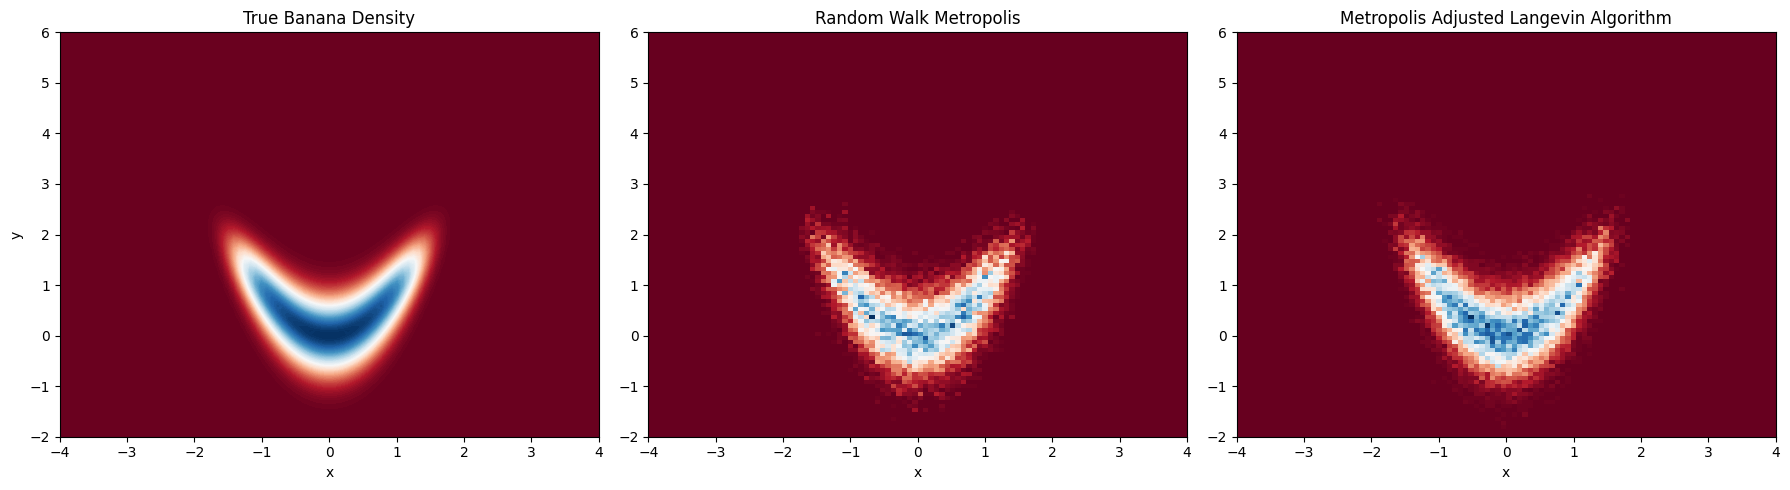

In [5]:
x_bb = np.linspace(-4, 4, 100)
y_bb = np.linspace(-2, 6, 100)
X_bb, Y_bb = np.meshgrid(x_bb, y_bb)
Z_bb = np.exp(log_banana(X_bb, Y_bb))

plt.figure(figsize=(18, 5))

# Ground Truth
plt.subplot(1, 3, 1)
plt.contourf(X_bb, Y_bb, Z_bb, 100, cmap='RdBu')
plt.title('True Banana Density')
plt.xlabel('x')
plt.ylabel('y')

# Random Walk MH results
plt.subplot(1, 3, 2)
plt.hist2d(samples_RW[0, burnin:n], samples_RW[1, burnin:n], 100, cmap='RdBu', 
           range=[[-4, 4], [-2, 6]], density=True)
plt.title('Random Walk Metropolis')
plt.xlabel('x')

# MALA results
plt.subplot(1, 3, 3)
plt.hist2d(samples_Langevin[0, burnin:n], samples_Langevin[1, burnin:n], 100, cmap='RdBu', 
            range=[[-4, 4], [-2, 6]], density=True)
plt.title('Metropolis Adjusted Langevin Algorithm')
plt.xlabel('x')

plt.tight_layout()
plt.show()